In [1]:
### Using code above to download Jobs_2026 folder from Google Drive to local machine. Uncomment the code below to run it.

## import gdown

## url ="https://drive.google.com/drive/folders/11uTPfwHiRohl2ljSYeFuo0KKBUP_1vk4?usp=sharing"

## gdown.download_folder(url, quiet=False, use_cookies=False)

In [2]:
## Code Snippet from Assignment 2 documentation used to read parquet files and create a Spark DataFrame.

import os
from pathlib import Path

import os
import sys
from pathlib import Path
from pyspark.sql import SparkSession

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .appName("JobPostingsAnalysis")
    .master("local[*]")
    .config("spark.driver.host", "localhost")
    .getOrCreate()
)

spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")

# Use sample mode while testing. Set to False for the full dataset.
USE_SAMPLE = False

data_dir = data_dir = Path("Jobs_2026")

parquet_files = sorted(data_dir.glob("*.parquet"))

if USE_SAMPLE:
    parquet_files = parquet_files[:1]

df = spark.read.parquet(*[str(path) for path in parquet_files])

# Parquet columns are uppercase; normalize once so the rest of the notebook can use lowercase names.
df = df.toDF(*[column.lower() for column in df.columns])

df.createOrReplaceTempView("job_postings")

# comment the lines below when rendering the submission
df.printSchema()
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/ubuntu/.local/lib/python3.12/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/17 06:12:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/17 06:12:16 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


root
 |-- id: string (nullable = true)
 |-- last_updated_date: string (nullable = true)
 |-- last_updated_timestamp: string (nullable = true)
 |-- duplicates: string (nullable = true)
 |-- posted: string (nullable = true)
 |-- expired: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- source_types: string (nullable = true)
 |-- sources: string (nullable = true)
 |-- url: string (nullable = true)
 |-- active_urls: string (nullable = true)
 |-- active_sources_info: string (nullable = true)
 |-- title_raw: string (nullable = true)
 |-- body: string (nullable = true)
 |-- modeled_expired: string (nullable = true)
 |-- modeled_duration: string (nullable = true)
 |-- company: string (nullable = true)
 |-- company_name: string (nullable = true)
 |-- company_raw: string (nullable = true)
 |-- company_is_staffing: string (nullable = true)
 |-- education_levels: string (nullable = true)
 |-- education_levels_name: string (nullable = true)
 |-- min_edulevels: string (nullable 

+------+-----------------+----------------------+----------+----------+-------+--------+------------+-----------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------------+----------------+---------+------------+-----------+-------------------+----------------+---------------------+-------------+------------------+-------------+------------------+---------------+--------------------+--------------------+--------------------+-------------+--------------------+-----------+----------------+-------------------+---------+-----------+-----------------+----+---------+------+-----------+---+--------+-----+----------+---------------+--------------------+---------------+--------------------+------------+-----------------+------------+-----------------+------+--------------------+------+-----------+------+-----------+------+-----------+------+--------------------+----------+--------------------+--------------------+------+-------

In [3]:
## Filtering job postings for selected NAICS code and displaying the results to ensure we have enough job postings.

from pyspark.sql import functions as F

TARGET_NAICS = "5417"
TARGET_CAREER = "Data Scientists"

data_scientists_df = df.filter(
    (F.col("naics4").cast("string") == TARGET_NAICS) &
    (F.col("onet_name") == TARGET_CAREER)
)

selected_df = data_scientists_df.select(
    "title_name",
    "company_name",
    "city_name",
    "state_name",
    "posted",
    "employment_type_name",
    "salary_from",
    "salary_to",
    "education_levels_name",
    "min_years_experience",
    "skills_name",
    "software_skills_name",
    "certifications_name",
    "onet_name",
    "naics4",
    "naics4_name"
)

print("Total matching postings:", selected_df.count())

selected_df.show(selected_df.count(), truncate=False)

Total matching postings: 212
+---------------+-------------------------------------------------------------------------+-------------------------------+---------------------------+----------+------------------------------------------+-----------+---------+----------------------------------------------------------------------------------------------------------------------------------+--------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------+-------------------+---------------+------+-----------+
|title_name     |company_name                                                             |city_name                      |state_name                 |posted    |employment_type_name                      |salary_from|salary_to|education_levels_name                            

In [4]:
print("Rows before duplicate removal:", data_scientists_df.count())

data_scientists_df = data_scientists_df.dropDuplicates(["id"])

print("Rows after duplicate removal:", data_scientists_df.count())

Rows before duplicate removal: 212


Rows after duplicate removal: 212


In [5]:
important_cols = [
    # Posting
    "posted",
    "title_name",
    "company_name",

    # Location
    "city_name",
    "state_name",

    # Job type / remote
    "employment_type_name",
    "remote_type_name",

    # Salary
    "salary_from",
    "salary_to",
    "original_pay_period",

    # Experience
    "min_years_experience",
    "max_years_experience",

    # Education
    "education_levels_name",

    # Skills
    "skills_name",
    "specialized_skills_name",
    "common_skills_name",
    "software_skills_name",
    "certifications_name",

    # Career
    "onet",
    "onet_name",

    # Industry
    "naics4",
    "naics4_name"
]

missing_counts = data_scientists_df.select([
    F.sum(
        (
            F.col(c).isNull() |
            (F.trim(F.col(c).cast("string")) == "") |
            (F.trim(F.col(c).cast("string")) == "[]")
        ).cast("int")
    ).alias(c)
    for c in important_cols
])

missing_counts.show(vertical=True)

-RECORD 0----------------------
 posted                  | 0   
 title_name              | 0   
 company_name            | 0   
 city_name               | 46  
 state_name              | 31  
 employment_type_name    | 63  
 remote_type_name        | 0   
 salary_from             | 153 
 salary_to               | 153 
 original_pay_period     | 151 
 min_years_experience    | 212 
 max_years_experience    | 212 
 education_levels_name   | 0   
 skills_name             | 25  
 specialized_skills_name | 26  
 common_skills_name      | 181 
 software_skills_name    | 212 
 certifications_name     | 212 
 onet                    | 0   
 onet_name               | 0   
 naics4                  | 0   
 naics4_name             | 212 



In [6]:
# labeling categorical missing values

from pyspark.sql import functions as F

def is_missing(c):
    return (
        F.col(c).isNull() |
        (F.trim(F.col(c).cast("string")) == "") |
        (F.trim(F.col(c).cast("string")) == "[]")
    )

categorical_cols = [
    "city_name",
    "state_name",
    "employment_type_name",
    "remote_type_name"
]

for c in categorical_cols:
    data_scientists_df = data_scientists_df.withColumn(
        c,
        F.when(
            is_missing(c),
            F.lit("Unknown")
        ).otherwise(F.col(c))
    )

In [7]:
# analyzing salary, experience, skills counts

def is_missing(c):
    return (
        F.col(c).isNull() |
        (F.trim(F.col(c).cast("string")) == "") |
        (F.trim(F.col(c).cast("string")) == "[]")
    )
    
salary_df = data_scientists_df.filter(
    ~is_missing("salary_from") &
    ~is_missing("salary_to") &
    ~is_missing("original_pay_period")
)

experience_df = data_scientists_df.filter(
    ~is_missing("min_years_experience")
)

skills_df = data_scientists_df.filter(
    ~is_missing("skills_name")
)

print("Total postings:", data_scientists_df.count())

print("Postings with salary data:", salary_df.count())

print("Postings with experience data:", experience_df.count())

print("Postings with skills data:", skills_df.count())


Total postings: 212
Postings with salary data: 59
Postings with experience data: 0
Postings with skills data: 187


In [8]:
# salary normalization and dealing with unknowns - converting all pay periods to annual and unknowns as NULL

data_scientists_df = (
    data_scientists_df
    .withColumn(
        "salary_from_num",
        F.expr("try_cast(salary_from as double)")
    )
    .withColumn(
        "salary_to_num",
        F.expr("try_cast(salary_to as double)")
    )
)

data_scientists_df = (
    data_scientists_df
    .withColumn(
        "annual_salary_from",
        F.when(
            F.lower(F.col("original_pay_period")) == "hourly",
            F.col("salary_from_num") * 2080
        ).otherwise(F.col("salary_from_num"))
    )
    .withColumn(
        "annual_salary_to",
        F.when(
            F.lower(F.col("original_pay_period")) == "hourly",
            F.col("salary_to_num") * 2080
        ).otherwise(F.col("salary_to_num"))
    )
)

# replace zero/negative salaries with NULL
data_scientists_df = (
    data_scientists_df
    .withColumn(
        "annual_salary_from",
        F.when(F.col("annual_salary_from") <= 0, F.lit(None))
         .otherwise(F.col("annual_salary_from"))
    )
    .withColumn(
        "annual_salary_to",
        F.when(F.col("annual_salary_to") <= 0, F.lit(None))
         .otherwise(F.col("annual_salary_to"))
    )
)

data_scientists_df.select(
    "salary_from",
    "salary_to",
    "original_pay_period",
    "annual_salary_from",
    "annual_salary_to"
).show(20, truncate=False)

+-----------+---------+-------------------+------------------+----------------+
|salary_from|salary_to|original_pay_period|annual_salary_from|annual_salary_to|
+-----------+---------+-------------------+------------------+----------------+
|           |         |                   |NULL              |NULL            |
|           |         |                   |NULL              |NULL            |
|           |         |                   |NULL              |NULL            |
|           |         |                   |NULL              |NULL            |
|206445.02  |309667.52|annual             |206445.02         |309667.52       |
|220000.00  |330000.00|annual             |220000.0          |330000.0        |
|           |         |                   |NULL              |NULL            |
|           |         |                   |NULL              |NULL            |
|           |         |                   |NULL              |NULL            |
|132500.00  |232000.00|annual           

In [9]:
salary_df = data_scientists_df.filter(
    (F.col("annual_salary_from") > 0) &
    (F.col("annual_salary_to") > 0)
)

salary_df.select(
    "annual_salary_from",
    "annual_salary_to"
).summary().show()

# 51 usable records for salary

+-------+------------------+-----------------+
|summary|annual_salary_from| annual_salary_to|
+-------+------------------+-----------------+
|  count|                51|               51|
|   mean|173299.31411764704|244484.2650980392|
| stddev|57610.333227088384|76508.58277814407|
|    min|           65000.0|          95000.0|
|    25%|          139200.0|         190700.0|
|    50%|          164000.0|         232000.0|
|    75%|         206445.02|         315000.0|
|    max|          336400.0|         405000.0|
+-------+------------------+-----------------+



In [10]:
data_scientists_df.select(
    "skills_name",
    "specialized_skills_name"
).printSchema()

data_scientists_df.select(
    "skills_name",
    "specialized_skills_name"
).show(10, truncate=False)

root
 |-- skills_name: string (nullable = true)
 |-- specialized_skills_name: string (nullable = true)

+-----------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------+
|skills_name                                                                                                      |specialized_skills_name                                                                                          |
+-----------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------+
|["Accountability", "Agentic Systems", "Analytics", "BigQuery"]                                                   |["Agentic Systems", "Analytics", "BigQuery"]                                               

In [11]:
# cleaning skills name

from pyspark.sql.types import ArrayType, StringType

data_scientists_df = data_scientists_df.withColumn(
    "skills_array",
    F.from_json(
        F.col("skills_name"),
        ArrayType(StringType())
    )
)

data_scientists_df.select(
    "skills_name",
    "skills_array"
).show(10, truncate=False)

skills_df = data_scientists_df.select(
    F.explode("skills_array").alias("skill")
)

top_skills = (
    skills_df
    .groupBy("skill")
    .count()
    .orderBy(F.desc("count"))
)

top_skills.show(20, truncate=False)

+-----------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------+
|skills_name                                                                                                      |skills_array                                                                                         |
+-----------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------+
|["Accountability", "Agentic Systems", "Analytics", "BigQuery"]                                                   |[Accountability, Agentic Systems, Analytics, BigQuery]                                               |
|["A/B Testing", "Advanced Analytics", "Analytics", "Business Problems", "Career Development", "Causal Inference"]|[A/B Testing,

In [12]:
# cleaning specialized skills

data_scientists_df = data_scientists_df.withColumn(
    "specialized_skills_array",
    F.from_json(
        F.col("specialized_skills_name"),
        ArrayType(StringType())
    )
)

data_scientists_df = data_scientists_df.withColumn(
    "specialized_skills_array",
    F.when(
        F.size(F.col("specialized_skills_array")) == 0,
        F.lit(None)
    ).otherwise(F.col("specialized_skills_array"))
)

specialized_skills_df = data_scientists_df.select(
    F.explode("specialized_skills_array").alias("specialized_skill")
)

top_specialized_skills = (
    specialized_skills_df
    .groupBy("specialized_skill")
    .count()
    .orderBy(F.desc("count"))
)

top_specialized_skills.show(20, truncate=False)

+-----------------------+-----+
|specialized_skill      |count|
+-----------------------+-----+
|Analytics              |98   |
|Algorithms             |33   |
|Automation             |33   |
|Advanced Analytics     |21   |
|Business Problems      |17   |
|Career Development     |16   |
|Biology                |15   |
|Artificial Intelligence|15   |
|AI Research            |11   |
|Agentic AI             |9    |
|Applied Mathematics    |9    |
|Business Intelligence  |9    |
|Biotechnology          |8    |
|Causal Inference       |7    |
|BigQuery               |7    |
|Applied Research       |7    |
|Business Analytics     |7    |
|Acting                 |7    |
|Bioinformatics         |6    |
|Banking                |6    |
+-----------------------+-----+
only showing top 20 rows


In [13]:
# converting missing skills and specialized skills to NULL

skill_cols = [
    "skills_name",
    "specialized_skills_name"
]

for c in skill_cols:
    data_scientists_df = data_scientists_df.withColumn(
        c,
        F.when(is_missing(c), F.lit(None))
         .otherwise(F.col(c))
    )
    
data_scientists_df.select(
    "skills_name",
    "specialized_skills_name"
).show(20, truncate=False)

# decided to only use these two skills columns and not software skills and certifications as they were all missing as common skills had MOSTLY (183) missing values

+------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------+
|skills_name                                                                                                                                                       |specialized_skills_name                                                                                                                          |
+------------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------+
|["Accountability", "Agentic Systems", "Analytics", "BigQuery"]    

In [14]:
# ensuring cleaning is done

analysis_cols = [
    "posted",
    "title_name",
    "company_name",
    "city_name",
    "state_name",
    "employment_type_name",
    "remote_type_name",
    "annual_salary_from",
    "annual_salary_to",
    "education_levels_name",
    "skills_name",
    "specialized_skills_name",
    "min_years_experience",
    "max_years_experience",
    "onet_name",
    "naics4"
]

missing_check = []

for c in analysis_cols:
    count = data_scientists_df.filter(
        is_missing(c)
    ).count()

    missing_check.append((c, count))

for col, count in missing_check:
    print(f"{col:30} {count}")

check_cols = [
    "employment_type_name",
    "remote_type_name",
    "state_name",
    "onet_name",
    "naics4",
]

for c in check_cols:
    print(f"\n--- {c} ---")

    data_scientists_df.groupBy(c) \
        .count() \
        .orderBy(F.desc("count")) \
        .show(50, truncate=False)

salary_df.select(
    "annual_salary_from",
    "annual_salary_to"
).summary().show()

posted                         0
title_name                     0
company_name                   0
city_name                      0
state_name                     0
employment_type_name           0
remote_type_name               0
annual_salary_from             161
annual_salary_to               161
education_levels_name          0
skills_name                    25
specialized_skills_name        26
min_years_experience           212
max_years_experience           212
onet_name                      0
naics4                         0

--- employment_type_name ---
+------------------------------------------+-----+
|employment_type_name                      |count|
+------------------------------------------+-----+
|Full Time                                 |121  |
|Unknown                                   |63   |
|Contract                                  |14   |
|Full Time, Temporary                      |4    |
|Full Time, Internship                     |3    |
|Full Time, Contract, In

In [15]:
# cleaning states
valid_states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island",
    "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah",
    "Vermont", "Virginia", "Washington", "West Virginia",
    "Wisconsin", "Wyoming", "District of Columbia"
]

data_scientists_df = data_scientists_df.withColumn(
    "state_name",
    F.when(
        F.col("state_name").isin(valid_states),
        F.col("state_name")
    ).otherwise("Unknown")
)

data_scientists_df.groupBy(
    "state_name"
).count().orderBy(
    F.desc("count")
).show(60, truncate=False)

+--------------------+-----+
|state_name          |count|
+--------------------+-----+
|Unknown             |95   |
|New York            |24   |
|California          |23   |
|District of Columbia|14   |
|Texas               |7    |
|Massachusetts       |7    |
|Virginia            |6    |
|North Carolina      |6    |
|Illinois            |5    |
|Ohio                |4    |
|Pennsylvania        |4    |
|Maryland            |4    |
|Minnesota           |2    |
|Michigan            |2    |
|New Jersey          |2    |
|Washington          |1    |
|Missouri            |1    |
|Kansas              |1    |
|Arizona             |1    |
|Tennessee           |1    |
|Florida             |1    |
|South Carolina      |1    |
+--------------------+-----+



In [16]:
data_scientists_df.groupBy(
    "city_name"
).count().orderBy(
    F.desc("count")
).show(60, truncate=False)

+-----------------------+-----+
|city_name              |count|
+-----------------------+-----+
|Unknown                |46   |
|New York               |25   |
|Washington             |15   |
|San Francisco          |7    |
|Remote                 |6    |
|California             |5    |
|Cambridge              |4    |
|Chicago                |4    |
|San                    |3    |
|CA                     |3    |
|Austin                 |3    |
|District of Columbia   |3    |
|San Jose               |3    |
|Raleigh                |2    |
|Dayton                 |2    |
|Pennsylvania           |2    |
|United States          |2    |
|Illinois               |2    |
|Pittsburgh             |2    |
|Livermore              |2    |
|Massachusetts          |2    |
|Columbia               |2    |
|Work At Home           |2    |
|Mountain View          |2    |
|Boston                 |2    |
|Phoenix                |1    |
|Ca                     |1    |
|Dallas                 |1    |
|; Resto

In [17]:
# cleaning cities
invalid_cities = [
    "Remote",
    "Work At Home",
    "California",
    "CA",
    "Ca",
    "District of Columbia",
    "Pennsylvania",
    "United States",
    "Illinois",
    "Massachusetts",
    "Texas",
    "VA",
    "IL",
    "Nevada",
    "Delaware",
    "US-NY"
]

data_scientists_df = data_scientists_df.withColumn(
    "city_name",
    F.when(
        F.col("city_name").isin(invalid_cities),
        "Unknown"
    )
    .when(
        F.col("city_name").startswith(";"),
        F.regexp_replace(F.col("city_name"), r"^;\s*", "")
    )
    .otherwise(F.col("city_name"))
)

data_scientists_df.groupBy("city_name") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(60, truncate=False)

+-------------------------------+-----+
|city_name                      |count|
+-------------------------------+-----+
|Unknown                        |80   |
|New York                       |25   |
|Washington                     |15   |
|San Francisco                  |7    |
|Cambridge                      |4    |
|Chicago                        |4    |
|San                            |3    |
|Austin                         |3    |
|San Jose                       |3    |
|Raleigh                        |2    |
|Dayton                         |2    |
|Pittsburgh                     |2    |
|Livermore                      |2    |
|Columbia                       |2    |
|Reston                         |2    |
|Mountain View                  |2    |
|Boston                         |2    |
|Phoenix                        |1    |
|Dallas                         |1    |
|Dearborn                       |1    |
|Schaumburg                     |1    |
|Grand Rapids                   |1    |


In [18]:
# market baseline EDA PART 1

# for website - titles with Data Scientists is 212

# salary distributions: creating a midpoint for our 51 usable records for salary
salary_df = salary_df.withColumn(
    "annual_salary_midpoint",
    (
        F.col("annual_salary_from") +
        F.col("annual_salary_to")
    ) / 2
)

salary_df.select(
    "annual_salary_from",
    "annual_salary_to",
    "annual_salary_midpoint"
).summary().show()


+-------+------------------+-----------------+----------------------+
|summary|annual_salary_from| annual_salary_to|annual_salary_midpoint|
+-------+------------------+-----------------+----------------------+
|  count|                51|               51|                    51|
|   mean|173299.31411764704|244484.2650980392|    208891.78960784312|
| stddev|57610.333227088384|76508.58277814407|     63987.84198070371|
|    min|           65000.0|          95000.0|               80000.0|
|    25%|          139200.0|         190700.0|              170000.0|
|    50%|          164000.0|         232000.0|              200000.0|
|    75%|         206445.02|         315000.0|              261000.0|
|    max|          336400.0|         405000.0|              362500.0|
+-------+------------------+-----------------+----------------------+



/home/ubuntu/.local/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


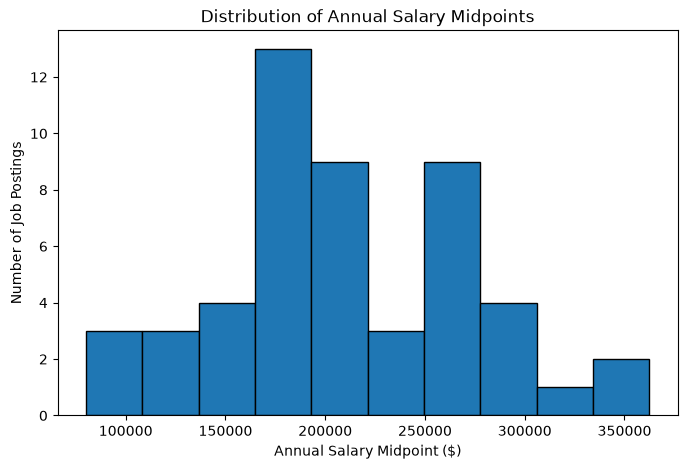

In [19]:
# histogram for visualization for salary midpoints

salary_pd = salary_df.select(
    "annual_salary_midpoint"
).toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    salary_pd["annual_salary_midpoint"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("Annual Salary Midpoint ($)")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of Annual Salary Midpoints")

plt.show()

In [20]:
# market baseline EDA PART 2 - for location patterns

state_counts = (
    data_scientists_df
    .groupBy("state_name")
    .count()
    .orderBy(F.desc("count"))
)

state_counts.show(truncate=False)

+--------------------+-----+
|state_name          |count|
+--------------------+-----+
|Unknown             |95   |
|New York            |24   |
|California          |23   |
|District of Columbia|14   |
|Texas               |7    |
|Massachusetts       |7    |
|Virginia            |6    |
|North Carolina      |6    |
|Illinois            |5    |
|Ohio                |4    |
|Pennsylvania        |4    |
|Maryland            |4    |
|Minnesota           |2    |
|Michigan            |2    |
|New Jersey          |2    |
|Washington          |1    |
|Missouri            |1    |
|Kansas              |1    |
|Arizona             |1    |
|Tennessee           |1    |
+--------------------+-----+
only showing top 20 rows


In [21]:
# market baseline EDA PART 3 

# experience patterns - for our NAICS all 212 records had missing min and max experiences so we will not be able to analyze experience patterns for our NAICS code.

# remote vs onsite patterns
data_scientists_df.groupBy(
    "remote_type_name"
).count().orderBy(
    F.desc("count")
).show(truncate=False)

+----------------+-----+
|remote_type_name|count|
+----------------+-----+
|Unknown         |111  |
|Remote          |45   |
|Hybrid          |42   |
|On-site         |14   |
+----------------+-----+



In [22]:
# market baseline EDA PART 4 - top employers
employer_counts = (
    data_scientists_df
    .groupBy("company_name")
    .count()
    .orderBy(F.desc("count"))
)

employer_counts.show(20, truncate=False)

+------------------------------------------+-----+
|company_name                              |count|
+------------------------------------------+-----+
|Amazon                                    |18   |
|Jobs.thermofisher.com                     |7    |
|Tiger-Analytics                           |6    |
|Profluent                                 |4    |
|Grvty                                     |3    |
|Pinterest                                 |3    |
|Chime                                     |3    |
|Optiver                                   |2    |
|LLNL                                      |2    |
|Forgeglobal                               |2    |
|Reddit                                    |2    |
|Amgen                                     |2    |
|Renesaselectronics                        |2    |
|Jobs.danaher.com                          |2    |
|Llnl                                      |2    |
|Fa-Evmr-Saasfaprod1.fa.ocs.oraclecloud.com|2    |
|Eeho.fa.us2.oraclecloud.com   

In [23]:
data_scientists_df.select(
    "company_name",
    "company_raw"
).filter(
    F.col("company_name").isin(
        "Jobs.thermofisher.com",
        "Jobs.danaher.com",
        "Fa-Evmr-Saasfaprod1.fa.ocs.oraclecloud.com",
        "Eeho.fa.us2.oraclecloud.com"
    )
).show(truncate=False)

+------------------------------------------+------------------------------------------+
|company_name                              |company_raw                               |
+------------------------------------------+------------------------------------------+
|Eeho.fa.us2.oraclecloud.com               |Eeho.fa.us2.oraclecloud.com               |
|Eeho.fa.us2.oraclecloud.com               |Eeho.fa.us2.oraclecloud.com               |
|Jobs.thermofisher.com                     |Jobs.thermofisher.com                     |
|Jobs.thermofisher.com                     |Jobs.thermofisher.com                     |
|Jobs.thermofisher.com                     |Jobs.thermofisher.com                     |
|Jobs.danaher.com                          |Jobs.danaher.com                          |
|Jobs.thermofisher.com                     |Jobs.thermofisher.com                     |
|Jobs.thermofisher.com                     |Jobs.thermofisher.com                     |
|Jobs.thermofisher.com          

In [24]:
data_scientists_df = data_scientists_df.dropDuplicates()

In [25]:
output_df = data_scientists_df.select(
    "posted",
    "title_name",
    "company_name",
    "city_name",
    "state_name",
    "employment_type_name",
    "remote_type_name",
    "annual_salary_from",
    "annual_salary_to",
    "education_levels_name",
    "skills_array",
    "specialized_skills_array",
    "min_years_experience",
    "max_years_experience",
    "onet_name",
    "naics4"
)

# Remove duplicates based on the final cleaned columns
output_df = output_df.dropDuplicates()

print("Final row count:", output_df.count())

output_df.toPandas().to_csv(
    "career_market_panel.csv",
    index=False
)

/home/ubuntu/.local/lib/python3.12/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Final row count: 208
